# I519 Companion Notebook: Genome Indexing with BWT/FM-index and Minimizers

This notebook accompanies the lecture deck on **genome indexing for compression, sequence search, and read mapping**.

The goal is not to build production-quality aligners. Instead, the examples are deliberately small so that you can see the main algorithmic ideas:

1. Why indexing is needed
2. Suffix arrays
3. Burrows–Wheeler Transform (BWT)
4. FM-index-style backward search
5. k-mers and minimizers
6. Seed lookup
7. Seed chaining
8. How these ideas connect to BWA/Bowtie and Minimap2

We will use the same toy DNA sequence from the slides:

```text
GATTACA$
```

The symbol `$` is a unique end marker that sorts before the DNA bases.

## 1. A naïve sequence-search baseline

Before building an index, we can search a reference by checking every possible starting position.

For a reference of length $n$ and a pattern of length $m$, this straightforward method can require roughly $O(nm)$ work in the worst case.

In [1]:
reference = "GATTACA"
pattern = "ACA"

matches = []
for i in range(len(reference) - len(pattern) + 1):
    if reference[i:i+len(pattern)] == pattern:
        matches.append(i)

print("Reference:", reference)
print("Pattern:  ", pattern)
print("Match positions:", matches)

Reference: GATTACA
Pattern:   ACA
Match positions: [4]


For a toy sequence this is trivial. For a multi-billion-base genome queried millions of times, repeatedly scanning the reference is inefficient.

The solution is to **preprocess the reference into an index**.

# Part I — Suffix arrays, BWT, and FM-index

## 2. Build all suffixes

A **suffix** is the substring beginning at a position and extending to the end of the sequence.

For `GATTACA$`, suffix 4 is:

```text
ACA$
```

In [2]:
text = "GATTACA$"

suffixes = [(i, text[i:]) for i in range(len(text))]

for i, suffix in suffixes:
    print(f"{i}: {suffix}")

0: GATTACA$
1: ATTACA$
2: TTACA$
3: TACA$
4: ACA$
5: CA$
6: A$
7: $


## 3. Construct a suffix array

A **suffix array** stores the starting positions of the suffixes after sorting them lexicographically.

In [3]:
sorted_suffixes = sorted(suffixes, key=lambda x: x[1])
suffix_array = [i for i, suffix in sorted_suffixes]

print("Sorted suffixes:")
for i, suffix in sorted_suffixes:
    print(f"{i}: {suffix}")

print("\nSuffix array:", suffix_array)

Sorted suffixes:
7: $
6: A$
4: ACA$
1: ATTACA$
5: CA$
0: GATTACA$
3: TACA$
2: TTACA$

Suffix array: [7, 6, 4, 1, 5, 0, 3, 2]


### Search with a suffix array

Because the suffixes are sorted, patterns sharing the same prefix occur together.

Below is a deliberately simple suffix-array search. Production implementations use binary search rather than scanning the sorted suffixes.

In [4]:
pattern = "ACA"

hits = [
    i
    for i, suffix in sorted_suffixes
    if suffix.startswith(pattern)
]

print("Pattern:", pattern)
print("Suffix-array matches:", hits)

Pattern: ACA
Suffix-array matches: [4]


## 4. Construct the Burrows–Wheeler Transform

One intuitive way to introduce the BWT is:

1. Generate every cyclic rotation.
2. Sort the rotations.
3. Take the last character of every sorted row.

For the tiny sequence `GATTACA$`, this is practical enough to do explicitly.

In [5]:
text = "GATTACA$"

rotations = [text[i:] + text[:i] for i in range(len(text))]
sorted_rotations = sorted(rotations)

print("All rotations:")
for r in rotations:
    print(r)

print("\nSorted rotations:")
for r in sorted_rotations:
    print(r)

bwt = "".join(r[-1] for r in sorted_rotations)
print("\nBWT:", bwt)

All rotations:
GATTACA$
ATTACA$G
TTACA$GA
TACA$GAT
ACA$GATT
CA$GATTA
A$GATTAC
$GATTACA

Sorted rotations:
$GATTACA
A$GATTAC
ACA$GATT
ATTACA$G
CA$GATTA
GATTACA$
TACA$GAT
TTACA$GA

BWT: ACTGA$TA


For `GATTACA$`, the BWT is:

```text
ACTGA$TA
```

The transform is a permutation of the original characters—it does not discard information.

## 5. First and last columns

In the sorted rotation matrix:

- **F** = first column
- **L** = last column = BWT

`F` is simply the characters of the original string in sorted order.

In [6]:
F = "".join(row[0] for row in sorted_rotations)
L = "".join(row[-1] for row in sorted_rotations)

print("F:", F)
print("L:", L)

F: $AAACGTT
L: ACTGA$TA


The important relationship is:

> The 1st occurrence of a character in `L` corresponds to the 1st occurrence of that character in `F`, the 2nd to the 2nd, and so on.

This is the basis of **LF-mapping**.

In [7]:
def occurrence_labels(s):
    counts = {}
    labels = []
    for ch in s:
        counts[ch] = counts.get(ch, 0) + 1
        labels.append(f"{ch}{counts[ch]}")
    return labels

print("F labels:", occurrence_labels(F))
print("L labels:", occurrence_labels(L))

F labels: ['$1', 'A1', 'A2', 'A3', 'C1', 'G1', 'T1', 'T2']
L labels: ['A1', 'C1', 'T1', 'G1', 'A2', '$1', 'T2', 'A3']


### Why does BWT help compression?

Sorting suffix/rotation contexts tends to bring similar contexts together. Their preceding characters therefore become clustered in `L`.

Real genomes contain repeated sequence contexts. In repetitive data, the BWT often contains long runs such as:

```text
AAAAAA...
CCCC...
TTTTTT...
```

Those runs are highly compressible using run-length and entropy-based coding.

The small `GATTACA$` example is designed for understanding the mechanics, not for demonstrating dramatic compression.

## 6. C table for FM-index search

For each character `c`, define:

**C[c] = number of characters in the text lexicographically smaller than c.**

In [8]:
alphabet = sorted(set(text))
counts = {c: text.count(c) for c in alphabet}

C = {}
running = 0
for c in alphabet:
    C[c] = running
    running += counts[c]

print("Alphabet:", alphabet)
print("Counts:", counts)
print("C table:", C)

Alphabet: ['$', 'A', 'C', 'G', 'T']
Counts: {'$': 1, 'A': 3, 'C': 1, 'G': 1, 'T': 2}
C table: {'$': 0, 'A': 1, 'C': 4, 'G': 5, 'T': 6}


## 7. Occ / rank table

`Occ(c, i)` tells us how many times character `c` occurs in the BWT before position `i`.

Here we use **half-open intervals** `[l, r)`, which makes the backward-search formulas particularly clean.

In [9]:
def build_occ(bwt):
    alphabet = sorted(set(bwt))
    occ = {c: [0] * (len(bwt) + 1) for c in alphabet}

    for i, ch in enumerate(bwt, start=1):
        for c in alphabet:
            occ[c][i] = occ[c][i-1]
        occ[ch][i] += 1

    return occ

occ = build_occ(bwt)

for c in sorted(occ):
    print(c, occ[c])

$ [0, 0, 0, 0, 0, 0, 1, 1, 1]
A [0, 1, 1, 1, 1, 2, 2, 2, 3]
C [0, 0, 1, 1, 1, 1, 1, 1, 1]
G [0, 0, 0, 0, 1, 1, 1, 1, 1]
T [0, 0, 0, 1, 1, 1, 1, 2, 2]


## 8. FM-index backward search

Suppose `[l, r)` is the interval containing suffixes beginning with pattern `P`.

To prepend a character `c` and search for `cP`:

\[
l' = C[c] + Occ(c,l)
\]

\[
r' = C[c] + Occ(c,r)
\]

If `l' < r'`, at least one match remains.

The striking part is that search proceeds **backward through the query**, without scanning the genome.

In [10]:
def backward_search(pattern, bwt, C, occ, verbose=True):
    l, r = 0, len(bwt)

    for c in reversed(pattern):
        if c not in C:
            return None

        l = C[c] + occ[c][l]
        r = C[c] + occ[c][r]

        if verbose:
            print(f"After adding {c!r}: interval = [{l}, {r})")

        if l >= r:
            return None

    return l, r

interval = backward_search("ACA", bwt, C, occ)
print("Final interval:", interval)

After adding 'A': interval = [1, 4)
After adding 'C': interval = [4, 5)
After adding 'A': interval = [2, 3)
Final interval: (2, 3)


## 9. Recover the matching genome positions

The FM-index identifies an interval in suffix-array order. If a suffix array—or sampled suffix-array information—is available, we can convert that interval back to genomic coordinates.

In [11]:
l, r = backward_search("ACA", bwt, C, occ, verbose=False)

matching_positions = suffix_array[l:r]

print("Matching suffix-array entries:", matching_positions)
print("Matched substrings:")
for pos in matching_positions:
    print(pos, text[pos:pos+3])

Matching suffix-array entries: [4]
Matched substrings:
4 ACA


### Try several patterns

In [12]:
for pattern in ["A", "TA", "ACA", "GAT", "AAA"]:
    interval = backward_search(pattern, bwt, C, occ, verbose=False)
    if interval is None:
        print(f"{pattern:>3}: no match")
    else:
        l, r = interval
        print(f"{pattern:>3}: positions {suffix_array[l:r]}")

  A: positions [6, 4, 1]
 TA: positions [3]
ACA: positions [4]
GAT: positions [0]
AAA: no match


## 10. A useful conceptual picture of BWT/FM-index

A short-read mapper can use the index approximately as follows:

```text
read
  ↓
exact or near-exact indexed search
  ↓
candidate genome location(s)
  ↓
alignment / extension
```

The index does not eliminate alignment. It makes **candidate discovery** much cheaper.

# Part II — k-mers and minimizers

## 11. Generate overlapping k-mers

A different approach is to use short exact substrings as **seeds**.

For a sequence of length `n`, there are `n-k+1` overlapping k-mers.

In [13]:
sequence = "ACGTCGATCGTA"
k = 4

kmers = [(i, sequence[i:i+k]) for i in range(len(sequence)-k+1)]

for pos, kmer in kmers:
    print(pos, kmer)

0 ACGT
1 CGTC
2 GTCG
3 TCGA
4 CGAT
5 GATC
6 ATCG
7 TCGT
8 CGTA


Indexing **every** k-mer is possible, but adjacent k-mers overlap heavily and therefore contain substantial redundancy.

Minimizers deliberately keep only a subset.

## 12. A deterministic hash for teaching

Python's built-in `hash()` changes between processes, so we will use a tiny deterministic hash for reproducibility.

This is only for demonstration—not a production hash function.

In [14]:
def simple_dna_hash(kmer):
    value = 0
    code = {"A": 0, "C": 1, "G": 2, "T": 3}
    for base in kmer:
        value = value * 4 + code[base]
    # Scramble slightly while remaining deterministic
    return (value * 17 + 13) % 101

for pos, kmer in kmers:
    print(pos, kmer, simple_dna_hash(kmer))

0 ACGT 68
1 CGTC 48
2 GTCG 77
3 TCGA 49
4 CGAT 80
5 GATC 87
6 ATCG 22
7 TCGT 100
8 CGTA 31


## 13. Select minimizers from sliding windows

Let:

- `k` = k-mer length
- `w` = number of consecutive k-mers in a minimizer window

For each window, select the k-mer with the smallest hash value.

We use the leftmost minimum to break ties.

In [15]:
def minimizers(sequence, k=4, w=4):
    kmers = [(i, sequence[i:i+k]) for i in range(len(sequence)-k+1)]
    hashed = [(pos, kmer, simple_dna_hash(kmer)) for pos, kmer in kmers]

    selected = []

    for start in range(len(hashed)-w+1):
        window = hashed[start:start+w]
        winner = min(window, key=lambda x: (x[2], x[0]))
        selected.append(winner)

    return hashed, selected

hashed, selected = minimizers(sequence, k=4, w=4)

print("All k-mers:")
for item in hashed:
    print(item)

print("\nWinner in each window:")
for item in selected:
    print(item)

All k-mers:
(0, 'ACGT', 68)
(1, 'CGTC', 48)
(2, 'GTCG', 77)
(3, 'TCGA', 49)
(4, 'CGAT', 80)
(5, 'GATC', 87)
(6, 'ATCG', 22)
(7, 'TCGT', 100)
(8, 'CGTA', 31)

Winner in each window:
(1, 'CGTC', 48)
(1, 'CGTC', 48)
(3, 'TCGA', 49)
(6, 'ATCG', 22)
(6, 'ATCG', 22)
(6, 'ATCG', 22)


Notice that adjacent windows often choose the **same minimizer**, because adjacent windows overlap by `w-1` k-mers.

We normally deduplicate repeated selections of the same `(position, k-mer)`.

In [16]:
def unique_minimizers(sequence, k=4, w=4):
    _, selected = minimizers(sequence, k, w)

    unique = []
    seen = set()
    for pos, kmer, h in selected:
        key = (pos, kmer)
        if key not in seen:
            unique.append((pos, kmer, h))
            seen.add(key)

    return unique

mins = unique_minimizers(sequence, k=4, w=4)

print("Sequence length:", len(sequence))
print("Number of k-mers:", len(kmers))
print("Unique minimizers:", len(mins))
print()
for x in mins:
    print(x)

Sequence length: 12
Number of k-mers: 9
Unique minimizers: 3

(1, 'CGTC', 48)
(3, 'TCGA', 49)
(6, 'ATCG', 22)


This is the central sparsification idea:

```text
all k-mers:     █ █ █ █ █ █ █ █ █
minimizers:       █     █       █
```

We retain enough local landmarks for mapping while indexing far fewer seeds.

## 14. Effect of window size w

A larger `w` usually produces fewer minimizers.

That means:

- less memory
- fewer seed lookups
- potentially lower sensitivity

In [17]:
sequence = "ACGTCGATCGTACCTGACTGACCT"

for w in [2, 3, 4, 5, 6, 8]:
    mins = unique_minimizers(sequence, k=4, w=w)
    print(f"w={w:2d}: {len(mins):2d} unique minimizers")

w= 2: 12 unique minimizers
w= 3:  9 unique minimizers
w= 4:  7 unique minimizers
w= 5:  5 unique minimizers
w= 6:  5 unique minimizers
w= 8:  3 unique minimizers


## 15. Why similar sequences share minimizers

Suppose a read differs from the reference by one substitution.

Only k-mers overlapping that changed base are directly destroyed. Exact k-mers farther away remain unchanged and can still generate shared minimizers.

In [18]:
reference = "ACGTCGATCGTACCTGACTG"
read      = "ACGTCGATCGTTCCTGACTG"

k = 4
w = 4

ref_mins = unique_minimizers(reference, k, w)
read_mins = unique_minimizers(read, k, w)

ref_set = {kmer for pos, kmer, h in ref_mins}
read_set = {kmer for pos, kmer, h in read_mins}

print("Reference minimizers:")
print(ref_mins)

print("\nRead minimizers:")
print(read_mins)

print("\nShared minimizer k-mers:")
print(sorted(ref_set & read_set))

Reference minimizers:
[(1, 'CGTC', 48), (3, 'TCGA', 49), (6, 'ATCG', 22), (10, 'TACC', 29), (11, 'ACCT', 0), (14, 'TGAC', 0)]

Read minimizers:
[(1, 'CGTC', 48), (3, 'TCGA', 49), (6, 'ATCG', 22), (10, 'TTCC', 37), (11, 'TCCT', 32), (14, 'TGAC', 0)]

Shared minimizer k-mers:
['ATCG', 'CGTC', 'TCGA', 'TGAC']


This is why sparse exact seeds can still find approximate matches:

> We do not require the entire read to match exactly. We only need enough unchanged local seeds to locate the right neighborhood.

## 16. Build a minimizer index for a reference

A simple minimizer index maps:

```text
minimizer k-mer → reference positions
```

In [19]:
from collections import defaultdict

def build_minimizer_index(reference, k=4, w=4):
    index = defaultdict(list)

    for pos, kmer, h in unique_minimizers(reference, k, w):
        index[kmer].append(pos)

    return dict(index)

reference = "TTTACGTCGATCGTACCTGACTGAAA"
index = build_minimizer_index(reference, k=4, w=4)

for kmer, positions in sorted(index.items()):
    print(kmer, "->", positions)

ACCT -> [14]
ACTG -> [19]
ATCG -> [9]
CGTC -> [4]
TACC -> [13]
TACG -> [2]
TCGA -> [6]
TGAC -> [17]


## 17. Map a read using shared minimizer seeds

For each minimizer in the read:

1. look it up in the reference minimizer index
2. create a seed hit `(read_position, reference_position)`

A true mapping usually creates several mutually consistent hits.

In [20]:
read = "ACGTCGATCGTTCCTGACTG"

read_mins = unique_minimizers(read, k=4, w=4)

hits = []

for read_pos, kmer, h in read_mins:
    for ref_pos in index.get(kmer, []):
        hits.append((read_pos, ref_pos, kmer))

print("Seed hits:")
for hit in hits:
    print(hit)

Seed hits:
(1, 4, 'CGTC')
(3, 6, 'TCGA')
(6, 9, 'ATCG')
(14, 17, 'TGAC')


## 18. Why seed hits form a diagonal

If a read maps without a large insertion/deletion, the difference

```text
reference_position - read_position
```

should be approximately constant across correct seed hits.

That is the simplest intuition behind **chaining**.

In [21]:
for read_pos, ref_pos, kmer in hits:
    diagonal = ref_pos - read_pos
    print(
        f"{kmer}: read={read_pos:2d}, ref={ref_pos:2d}, "
        f"ref-read={diagonal:2d}"
    )

CGTC: read= 1, ref= 4, ref-read= 3
TCGA: read= 3, ref= 6, ref-read= 3
ATCG: read= 6, ref= 9, ref-read= 3
TGAC: read=14, ref=17, ref-read= 3


## 19. A tiny chaining demonstration

Production tools such as Minimap2 use sophisticated dynamic programming to score chains.

Here we use an intentionally simplified idea: group seeds by approximately equal diagonal.

In [22]:
from collections import Counter

diagonals = [ref_pos - read_pos for read_pos, ref_pos, kmer in hits]
counts = Counter(diagonals)

print("Seed counts by diagonal:")
for d, n in counts.most_common():
    print(f"diagonal {d:3d}: {n} seeds")

if counts:
    best_diagonal, n = counts.most_common(1)[0]
    print("\nBest candidate mapping offset:", best_diagonal)

Seed counts by diagonal:
diagonal   3: 4 seeds

Best candidate mapping offset: 3


## 20. Visualize seed hits

Correct seed hits tend to lie near a diagonal in query/reference coordinate space.

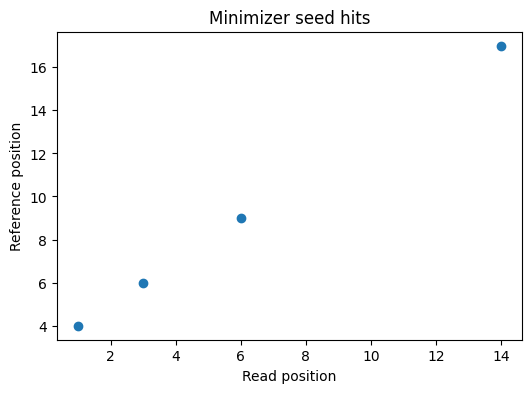

In [23]:
import matplotlib.pyplot as plt

x = [read_pos for read_pos, ref_pos, kmer in hits]
y = [ref_pos for read_pos, ref_pos, kmer in hits]

plt.figure(figsize=(6, 4))
plt.scatter(x, y)
plt.xlabel("Read position")
plt.ylabel("Reference position")
plt.title("Minimizer seed hits")
plt.show()

## 21. BWT/FM-index vs minimizers

| Idea | BWT / FM-index | Minimizers |
|---|---|---|
| Representation | compressed full-text index | sparse k-mer index |
| Query operation | backward search | hash lookup |
| Why it saves work | compactly represents searchable suffix information | stores only selected seeds |
| Candidate generation | suffix-array interval | seed hits |
| Next step | alignment / extension | chaining → alignment |
| Classic application | short-read mapping | long-read / assembly mapping |

A useful summary is:

```text
BWT/FM-index:
read → backward/index search → candidate positions → alignment

Minimizers:
read → minimizers → hash lookup → seed hits → chaining → alignment
```

# Exercises

## Exercise 1 — BWT by hand

Change the DNA sequence below to another short sequence ending in `$`.

1. Generate the rotations.
2. Sort them.
3. Compute the BWT.
4. Compare the result with your handwritten answer.

In [24]:
exercise_text = "ACGTAC$"

rotations = [
    exercise_text[i:] + exercise_text[:i]
    for i in range(len(exercise_text))
]

for row in sorted(rotations):
    print(row)

print("BWT =", "".join(row[-1] for row in sorted(rotations)))

$ACGTAC
AC$ACGT
ACGTAC$
C$ACGTA
CGTAC$A
GTAC$AC
TAC$ACG
BWT = CT$AACG


## Exercise 2 — FM-index search

Using the functions above, search `GATTACA$` for:

- `TA`
- `ACA`
- `TT`
- `AAA`

Which patterns have zero, one, or multiple matches?

In [25]:
# Write your experiment here.

## Exercise 3 — Minimizer parameters

For the sequence below, try several combinations of `k` and `w`.

Questions:

1. What happens as `w` increases?
2. What happens as `k` increases?
3. Which setting produces the sparsest set of seeds?

In [26]:
exercise_sequence = "ACGTCGATCGTACCTGACTGACCT"

# Example:
# print(unique_minimizers(exercise_sequence, k=4, w=4))

## Exercise 4 — Introduce mutations

Make one, two, and three substitutions in a read derived from the reference.

Measure how many minimizers remain shared with the reference.

This illustrates the sensitivity trade-off between exact seeding and approximate sequence similarity.

In [27]:
# Create mutated reads and compare their minimizer sets here.

# Take-home messages

- **Suffix arrays** sort genome suffixes to support indexed sequence search.
- **BWT** reorganizes sequence context in a reversible way that often improves compressibility.
- **FM-index** adds rank/occurrence information so patterns can be searched backward without scanning the reference.
- **Minimizers** sparsify overlapping k-mers by choosing representative seeds from sliding windows.
- Similar sequences tend to retain shared minimizers, allowing approximate mapping from exact local seeds.
- **Chaining** combines consistent seed hits before expensive base-level alignment.
- These ideas underlie influential genome-mapping strategies such as **BWA/Bowtie-style FM-index mapping** and **Minimap2-style minimizer mapping**.